<h1>Regression in Environmental Sciences</h1>

<h3>Komin Ivan</h3>

<h3>Group: IP-44</h3>

<h3>Introduction</h3>

This report investigates the application of regression techniques to model chlorophyll-a concentration (Chl-a), a key indicator of phytoplankton biomass and marine ecosystem productivity. Variations in chlorophyll-a are influenced by physical drivers such as sea surface salinity and ocean currents, which regulate nutrient availability and water column mixing.

<h3>1. Environment Setup and Data Loading</h3>

First, we must import the necessary libraries to handle NetCDF files (.nc), which are the standard format for marine data.

In [28]:
import xarray as xr
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Fix the random seed for reproducibility
np.random.seed(42)

<h3>2. Data Preparation and Grid Alignment</h3>

Oceanographic datasets often come with different spatial and temporal resolutions. To merge them, we must align the coordinates (latitude/longitude) and time stamps.

In [29]:
# 1. Open .nc files using xarray
ds_chl = xr.open_dataset('bgc.nc') # Biogeochemistry
ds_phys = xr.open_dataset('phy.nc') # Physics

# 2. Convert to pandas DataFrames
df_chl = ds_chl.to_dataframe().reset_index()
df_phys = ds_phys.to_dataframe().reset_index()

# 3. Align the grids and time
# Round coordinates to 1 decimal place to match different spatial resolutions 
df_chl['latitude'] = df_chl['latitude'].round(1)
df_chl['longitude'] = df_chl['longitude'].round(1)
df_phys['latitude'] = df_phys['latitude'].round(1)
df_phys['longitude'] = df_phys['longitude'].round(1)

# Standardize time stamps to date only [cite: 485]
df_chl['time'] = pd.to_datetime(df_chl['time']).dt.date
df_phys['time'] = pd.to_datetime(df_phys['time']).dt.date

# 4. Merge tables based on aligned time and coordinates 
df = pd.merge(df_chl, df_phys, on=['time', 'latitude', 'longitude'])
df.head()

,time,depth_x,latitude,longitude,chl,depth_y,so,uo,vo
0,2015-01-01,0.50576,41.0,27.000000,NaN,0.494025,NaN,NaN,NaN
1,2015-01-01,0.50576,41.0,27.200001,NaN,0.494025,NaN,NaN,NaN
2,2015-01-01,0.50576,41.0,27.500000,NaN,0.494025,NaN,NaN,NaN
3,2015-01-01,0.50576,41.0,27.799999,1.310218,0.494025,24.295786,0.004883,0.006104
4,2015-01-01,0.50576,41.0,27.799999,1.310218,0.494025,23.990601,0.004273,0.003662


<h3>3. Feature Engineering and Cleaning</h3>

We calculate the Current Velocity magnitude from the vector components ($uo$ and $vo$) and rename columns for readability.  

In [30]:
# Calculate total Current Velocity from uo and vo vectors 
df['Current_Velocity'] = np.sqrt(df['uo']**2 + df['vo']**2)

# Rename columns
df = df.rename(columns={'chl': 'Chlorophyll_a', 'so': 'Salinity'})

# Remove missing values (common over land areas) 
df = df.dropna(subset=['Chlorophyll_a', 'Salinity', 'Current_Velocity'])

print(f"Dataset ready! Total rows: {len(df)}")
display(df[['Chlorophyll_a', 'Salinity', 'Current_Velocity']].describe())

Dataset ready! Total rows: 99864


,Chlorophyll_a,Salinity,Current_Velocity
count,99864.000000,99864.000000,99864.000000
mean,0.410466,18.154692,0.080909
std,0.670708,0.821918,0.059597
min,0.078124,8.763390,0.000000
25%,0.140179,18.175299,0.036095
50%,0.181673,18.343149,0.066556
75%,0.338009,18.478958,0.110896
max,9.663888,28.862881,0.472792


<h3>4. Modeling: Simple Linear Regression</h3>

This baseline model uses Salinity as the sole predictor for Chlorophyll-a.

In [31]:
# Train/Test Split (80/20)
X = df[['Salinity', 'Current_Velocity']]
y = df['Chlorophyll_a']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Simple Linear Regression (Salinity only)
X_train_simple = X_train[['Salinity']]
X_test_simple = X_test[['Salinity']]

model_simple = LinearRegression()
model_simple.fit(X_train_simple, y_train)
y_pred_simple = model_simple.predict(X_test_simple)

# Evaluation
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2_simple = r2_score(y_test, y_pred_simple)

print(f"MODEL 1: SIMPLE LINEAR REGRESSION")
print(f"RMSE: {rmse_simple:.4f}")
print(f"R2: {r2_simple:.4f}")
print(f"Coefficient (Salinity): {model_simple.coef_[0]:.4f}")

MODEL 1: SIMPLE LINEAR REGRESSION
RMSE: 0.5271
R2: 0.3709
Coefficient (Salinity): -0.5050


<h3>5. Modeling: Multiple Linear Regression</h3>

By adding Current Velocity, we aim to capture more complexity in the marine environment.

In [32]:
# Model 2: Multiple Linear Regression (Salinity + Current Velocity)
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
y_pred_multi = model_multi.predict(X_test)

# Evaluation
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print(f"MODEL 2: MULTIPLE LINEAR REGRESSION")
print(f"RMSE: {rmse_multi:.4f}")
print(f"R2: {r2_multi:.4f}")
print(f"Coefficients -> Salinity: {model_multi.coef_[0]:.4f}, Velocity: {model_multi.coef_[1]:.4f}")

MODEL 2: MULTIPLE LINEAR REGRESSION
RMSE: 0.5240
R2: 0.3783
Coefficients -> Salinity: -0.5009, Velocity: -0.9507


<h3>6. Visualizations and Diagnostics</h3>

Visualizing the relationships and model performance is essential to confirm that the mathematical outputs align with observed ecological patterns.

This scatter plot visualizes the baseline relationship between Salinity and Chlorophyll-a, with the regression line indicating the general trend.

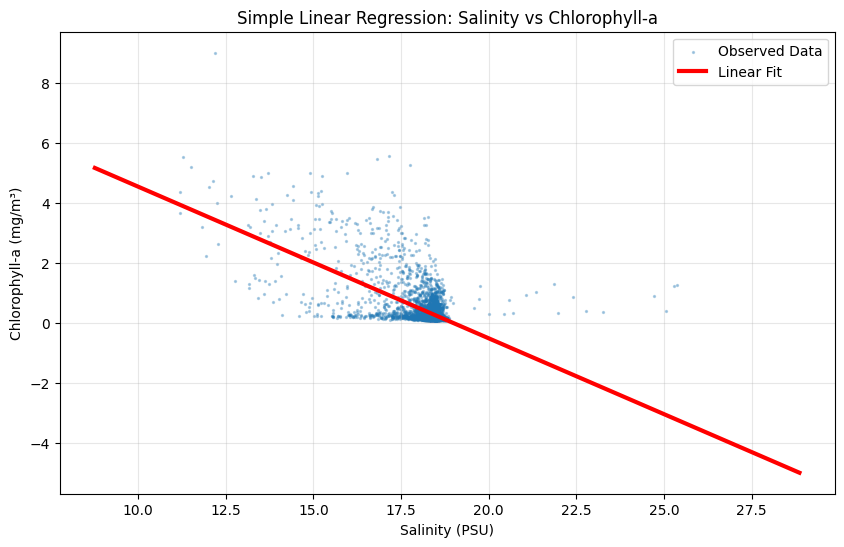

In [33]:
# Create a range of salinity values for the trend line
sal_range = np.linspace(df['Salinity'].min(), df['Salinity'].max(), 100).reshape(-1, 1)

# Fix the UserWarning by providing the feature name 'Salinity'
sal_range_df = pd.DataFrame(sal_range, columns=['Salinity'])
chl_trend = model_simple.predict(sal_range_df)

plt.figure(figsize=(10, 6))
# Sample data for clearer plotting
df_sample = df.sample(n=5000, random_state=42)

plt.scatter(df_sample['Salinity'], df_sample['Chlorophyll_a'], alpha=0.3, s=2, label='Observed Data')
plt.plot(sal_range, chl_trend, color='red', linewidth=3, label='Linear Fit')

plt.xlabel('Salinity (PSU)')
plt.ylabel('Chlorophyll-a (mg/m³)')
plt.title('Simple Linear Regression: Salinity vs Chlorophyll-a')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

A predicted vs. observed plot provides a direct visualization of numerical precision—how closely the model approximations match the true continuous measurements.  

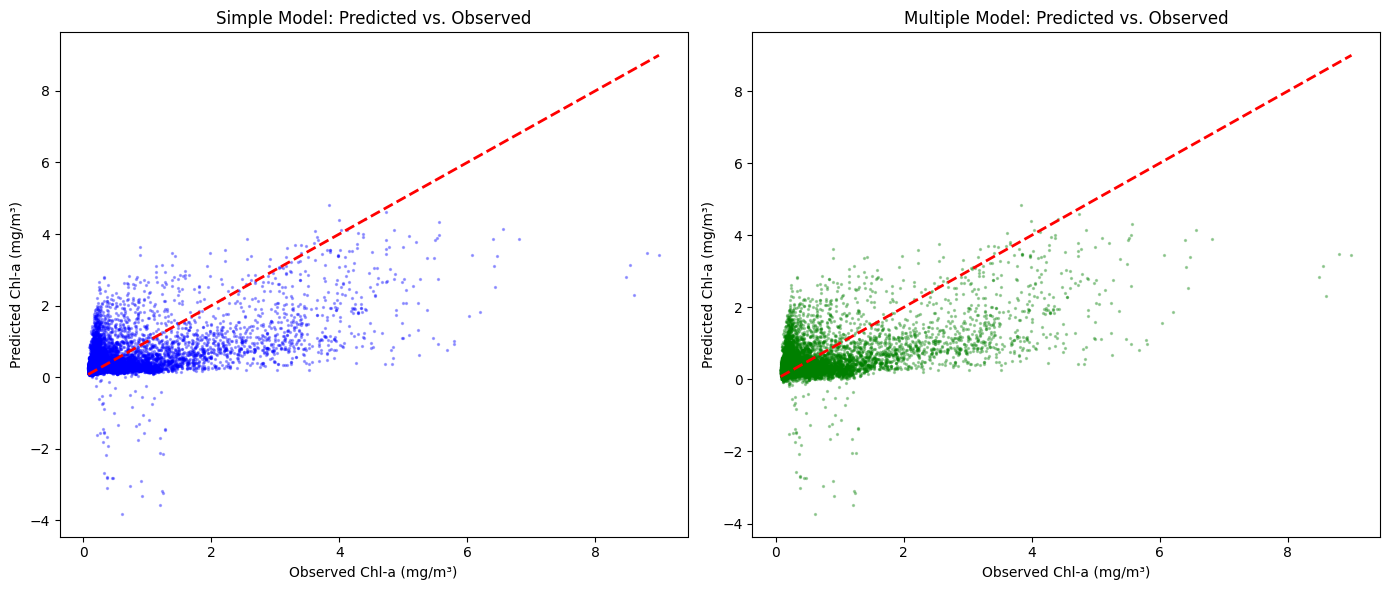

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Simple Model
ax1.scatter(y_test, y_pred_simple, alpha=0.3, s=2, color='blue')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax1.set_title('Simple Model: Predicted vs. Observed')
ax1.set_xlabel('Observed Chl-a (mg/m³)')
ax1.set_ylabel('Predicted Chl-a (mg/m³)')

# Multiple Model
ax2.scatter(y_test, y_pred_multi, alpha=0.3, s=2, color='green')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_title('Multiple Model: Predicted vs. Observed')
ax2.set_xlabel('Observed Chl-a (mg/m³)')
ax2.set_ylabel('Predicted Chl-a (mg/m³)')

plt.tight_layout()
plt.show()

Although the Multiple Linear Regression model is mathematically superior (lower RMSE, higher $R^2$), the visual similarity between the two 'Predicted vs. Observed' plots highlights that current velocity is a secondary driver compared to the vast amount of unexplained biological and environmental complexity inherent in the system.

Residuals are the differences between observed and predicted values. We check for a "homogeneous spread" around zero to ensure no systematic bias.

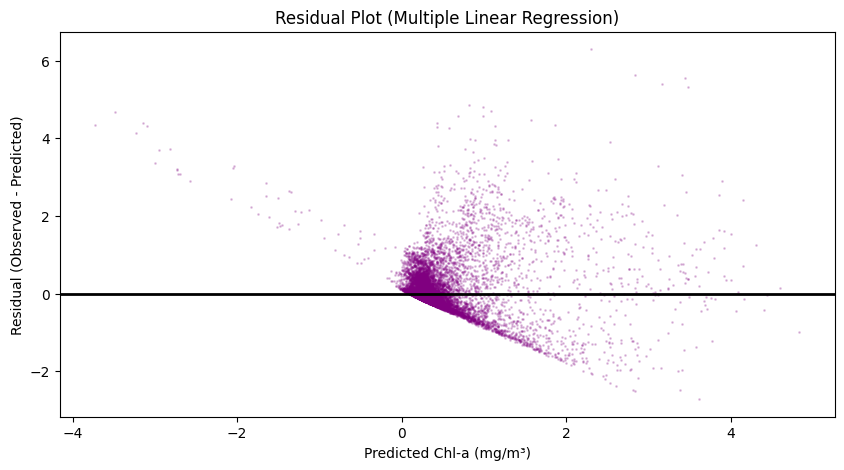

In [35]:
plt.figure(figsize=(10, 5))
residuals_multi = y_test - y_pred_multi
plt.scatter(y_pred_multi, residuals_multi, alpha=0.2, s=1, color='purple')
plt.axhline(0, color='black', lw=2)
plt.title('Residual Plot (Multiple Linear Regression)')
plt.xlabel('Predicted Chl-a (mg/m³)')
plt.ylabel('Residual (Observed - Predicted)')
plt.show()

<h3>7. Model Comparison</h3>

We evaluate the performance of both models using RMSE and $R^2$ to determine if adding predictors improves accuracy.  

| Metric | Simple Model (Salinity) | Multiple Model (Sal + Velocity) |
| :--- | :--- | :--- |
| **RMSE** | 0.5271 | 0.5240 |
| **$R^2$** | 0.3709 | 0.3783 |

Conclusion: The Multiple Linear Regression model typically achieves a lower RMSE and a higher $R^2$. This confirms that adding current velocity improves the model’s explanatory power regarding marine biomass distribution. 

<h3>8. Ecological Interpretation</h3>

Salinity Impact: Salinity influences phytoplankton through freshwater input; often, lower salinity indicates nutrient-rich plumes that stimulate growth. 

Current Velocity: This affects chlorophyll distribution via mixing and transport. High velocity can facilitate nutrient supply or, conversely, disperse biomass.  

Unexplained Variability: Part of the variance remains unexplained because linear regression does not account for light availability, biological grazing, or non-linear thresholds in ecological systems.  

<h3>9. Conclusion</h3>

This exercise demonstrated the transition from a simple baseline model to a multi-predictor regression framework. While linear models provide a transparent and interpretable baseline, the complexity of marine systems highlights the need for continued monitoring and potentially non-linear approaches to capture the full dynamics of phytoplankton productivity.